In [57]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'src').exists(): ROOT = Path.cwd().parents[2]
RESULTS_PATH = ROOT / 'src/modeling/model_outputs/modal_tabnet_outputs/results.parquet'
STRATEGY_PATH = ROOT / 'src/data/model_staging/strat_table.parquet'
LEDGER_PATH = ROOT / 'tabnet_trade_ledger.csv'
INITIAL_CAPITAL, POSITION_SIZE, TAKE_PROFIT = 50_000.0, 200.0, 0.02
DRIFT_OFFSETS = range(2, 11)


In [58]:
results = pl.read_parquet(RESULTS_PATH)
daily = pl.read_parquet(STRATEGY_PATH)
signals = results.filter(pl.col('target_class_predicted').is_in([1, 2]) & (pl.col('earnings_date') < pl.datetime(2026, 1, 1)))
join_cols = ['symbol', 'date', 'entry_date', 'close_t10']
for offset in DRIFT_OFFSETS: join_cols += [f'high_t+{offset}', f'date_t+{offset}']
signals = signals.join(daily.select(join_cols), left_on=['symbol', 'earnings_date'], right_on=['symbol', 'date'], how='left')
required = ['entry_price', 'entry_date', 'close_t10']
for offset in DRIFT_OFFSETS: required += [f'high_t+{offset}', f'date_t+{offset}']
signals = signals.drop_nulls(required).with_columns((pl.col('close_t10') / pl.col('entry_price') - 1).alias('close_t10_return'))
print(f'{len(signals):,} buy signals')


8,221 buy signals


In [59]:
def build_trades(signals, cost_bps=0.0, slippage_bps=0.0):
    round_trip = 2 * (cost_bps + slippage_bps) / 10_000
    trades = []
    for row in signals.iter_rows(named=True):
        exit_date, gross_return = row['date_t+10'], row['close_t10_return']
        for offset in DRIFT_OFFSETS:
            if row[f'high_t+{offset}'] / row['entry_price'] - 1 > TAKE_PROFIT:
                exit_date, gross_return = row[f'date_t+{offset}'], TAKE_PROFIT
                break
        trades.append({'symbol': row['symbol'], 'signal_date': row['earnings_date'], 'entry_date': row['entry_date'], 'entry_price': row['entry_price'], 'exit_date': exit_date, 'threshold': TAKE_PROFIT, 'model_fold': row.get('fold_num'), 'gross_pnl': POSITION_SIZE * gross_return, 'transaction_costs': POSITION_SIZE * cost_bps / 10_000 * 2, 'slippage': POSITION_SIZE * slippage_bps / 10_000 * 2, 'net_pnl': POSITION_SIZE * (gross_return - round_trip)})
    return pl.DataFrame(trades).sort(['entry_date', 'exit_date', 'symbol'])

def cash_filter(trades):
    events = []
    for i, row in enumerate(trades.iter_rows(named=True)): events += [(row['entry_date'], 1, i), (row['exit_date'], 0, i)]
    events.sort()  # exits (0) are processed before entries (1)
    cash, entered, skipped = INITIAL_CAPITAL, set(), 0
    for _, kind, i in events:
        if kind == 0 and i in entered: cash += POSITION_SIZE + trades[i, 'net_pnl']
        elif kind == 1 and cash >= POSITION_SIZE: cash -= POSITION_SIZE; entered.add(i)
        elif kind == 1: skipped += 1
    return trades.with_row_index('i').filter(pl.col('i').is_in(sorted(entered))).drop('i'), skipped


In [60]:
trades, skipped = cash_filter(build_trades(signals, cost_bps=0, slippage_bps=0))
trades.write_csv(LEDGER_PATH)
pnl_by_day = trades.group_by('exit_date').agg(pl.sum('net_pnl').alias('pnl'))
equity = daily.select(pl.col('date').alias('exit_date')).unique().sort('exit_date').join(pnl_by_day, on='exit_date', how='left').with_columns(pl.col('pnl').fill_null(0.0)).with_columns((INITIAL_CAPITAL + pl.col('pnl').cum_sum()).alias('equity'))
values = equity['equity'].to_numpy(); previous = np.r_[INITIAL_CAPITAL, values[:-1]]; returns = (values - previous) / previous
running_max = np.maximum.accumulate(values); std = returns.std(ddof=1) if len(returns) > 1 else 0
print({'trades': len(trades), 'skipped': skipped, 'net_pnl': float(trades['net_pnl'].sum()), 'win_rate': float((trades['net_pnl'] > 0).mean()), 'sharpe': float(returns.mean() / std * np.sqrt(252)) if std else 0.0, 'max_drawdown': float((values / running_max - 1).min()), 'final_equity': float(values[-1])})


{'trades': 8221, 'skipped': 0, 'net_pnl': 6636.775691998213, 'win_rate': 0.7586668288529376, 'sharpe': 1.3105366085255212, 'max_drawdown': -0.04450503350047563, 'final_equity': 56269.09159038704}


In [61]:
trades = trades.with_columns([(pl.col('net_pnl') / POSITION_SIZE).alias('trade_return'), (pl.col('exit_date') - pl.col('entry_date')).dt.total_days().alias('holding_days'), pl.col('exit_date').dt.strftime('%Y-%m').alias('month'), (pl.col('exit_date').dt.year().cast(pl.Utf8) + ' Q' + pl.col('exit_date').dt.quarter().cast(pl.Utf8)).alias('quarter')])
equity = equity.with_columns([((pl.col('equity') / pl.col('equity').shift(1).fill_null(INITIAL_CAPITAL)) - 1).alias('daily_return'), (pl.col('equity') / pl.col('equity').cum_max() - 1).alias('drawdown')])
monthly = trades.group_by('month').agg(pl.sum('net_pnl').alias('pnl')).sort('month')
quarterly = trades.group_by('quarter').agg(pl.sum('net_pnl').alias('pnl')).sort('quarter')
by_symbol = trades.group_by('symbol').agg([pl.sum('net_pnl').alias('pnl'), pl.len().alias('trades')]).sort('pnl')
rolling_win = trades.select((pl.col('net_pnl') > 0).cast(pl.Float64).rolling_mean(window_size=50).alias('win_rate'))
entry_counts = trades.group_by('entry_date').len().rename({'entry_date':'date','len':'entries'}); exit_counts = trades.group_by('exit_date').len().rename({'exit_date':'date','len':'exits'})
activity = daily.select('date').unique().sort('date').join(entry_counts, on='date', how='left').join(exit_counts, on='date', how='left').with_columns([pl.col('entries').fill_null(0), pl.col('exits').fill_null(0)]).with_columns((pl.col('entries').cum_sum() - pl.col('exits').cum_sum()).alias('open_positions')).with_columns((pl.col('open_positions') * POSITION_SIZE).alias('capital_exposure'))
PLOT_START = trades['entry_date'].min()
PLOT_END = trades['exit_date'].max()


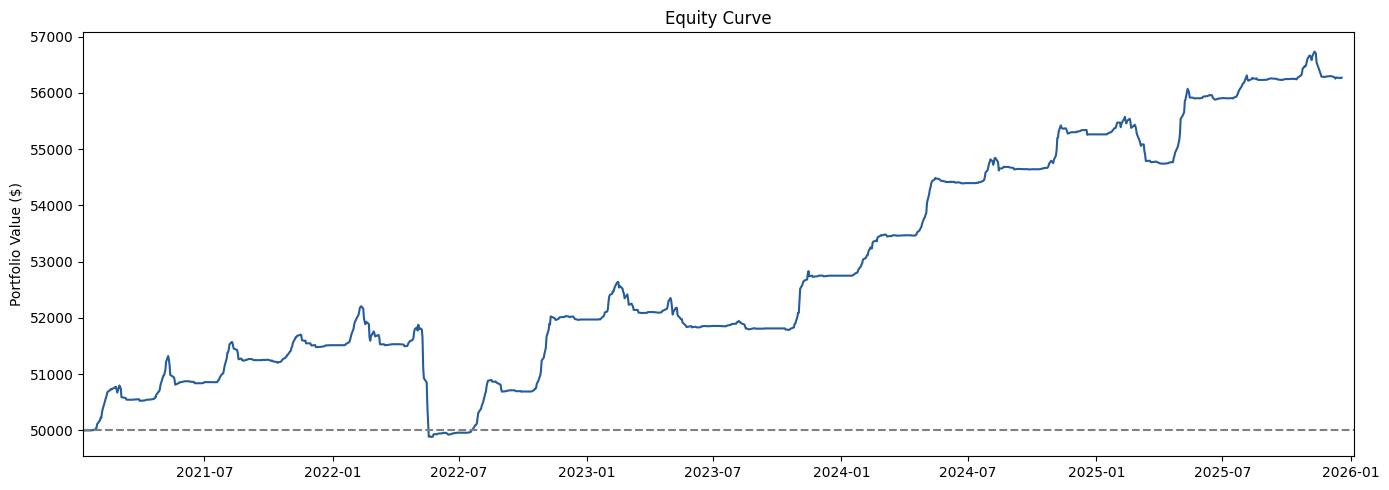

In [62]:
plt.figure(figsize=(14, 5)); plt.plot(equity['exit_date'], equity['equity'], color='#245c9c'); plt.axhline(INITIAL_CAPITAL, color='gray', ls='--'); plt.xlim(PLOT_START, PLOT_END); plt.title('Equity Curve'); plt.ylabel('Portfolio Value ($)'); plt.tight_layout(); plt.show()


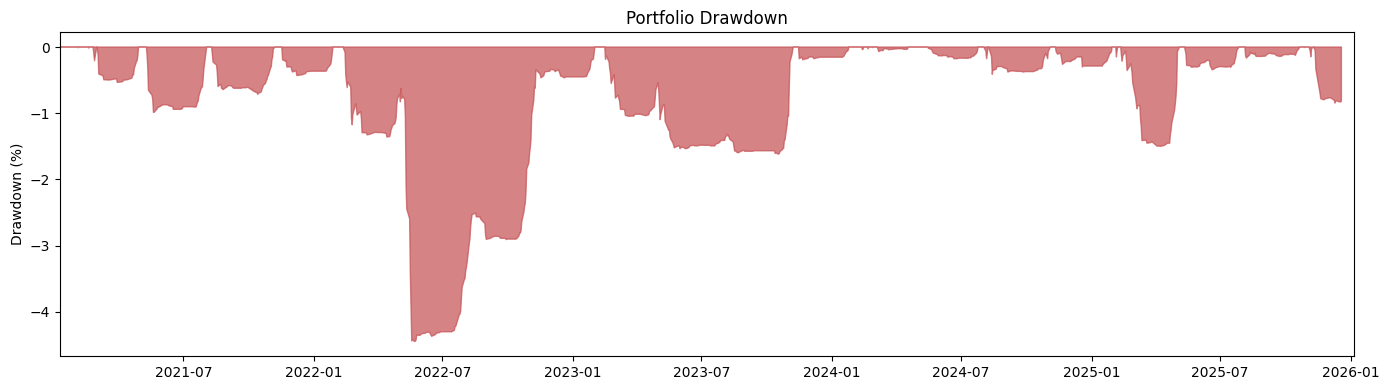

In [63]:
plt.figure(figsize=(14, 4)); plt.fill_between(equity['exit_date'].to_list(), equity['drawdown'].to_numpy() * 100, 0, color='#c44e52', alpha=.7); plt.xlim(PLOT_START, PLOT_END); plt.title('Portfolio Drawdown'); plt.ylabel('Drawdown (%)'); plt.tight_layout(); plt.show()


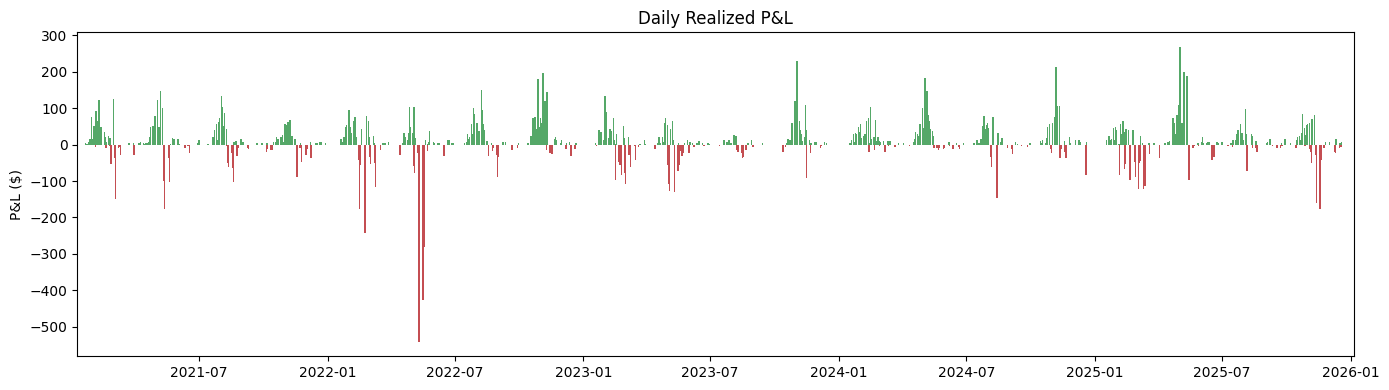

In [64]:
plt.figure(figsize=(14, 4)); colors = np.where(equity['pnl'].to_numpy() >= 0, '#55a868', '#c44e52'); plt.bar(equity['exit_date'], equity['pnl'], color=colors, width=2); plt.xlim(PLOT_START, PLOT_END); plt.title('Daily Realized P&L'); plt.ylabel('P&L ($)'); plt.tight_layout(); plt.show()


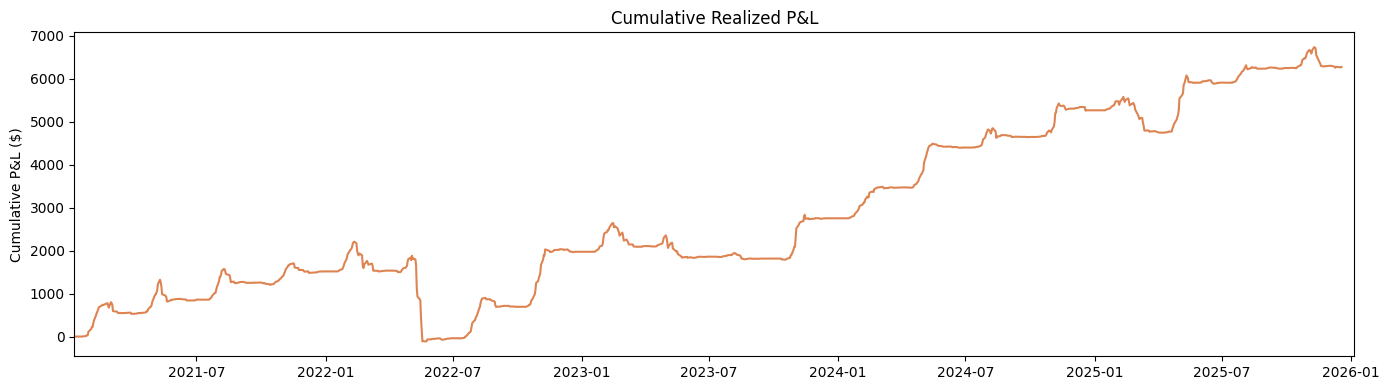

In [65]:
plt.figure(figsize=(14, 4)); plt.plot(equity['exit_date'], equity['pnl'].cum_sum(), color='#dd8452'); plt.xlim(PLOT_START, PLOT_END); plt.title('Cumulative Realized P&L'); plt.ylabel('Cumulative P&L ($)'); plt.tight_layout(); plt.show()


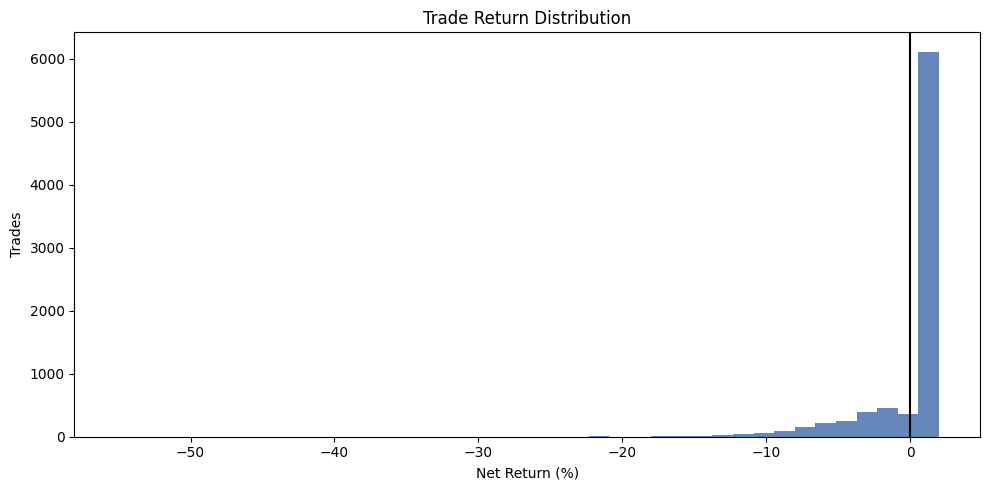

In [66]:
plt.figure(figsize=(10, 5)); plt.hist(trades['trade_return'].to_numpy() * 100, bins=40, color='#4c72b0', alpha=.85); plt.axvline(0, color='black'); plt.title('Trade Return Distribution'); plt.xlabel('Net Return (%)'); plt.ylabel('Trades'); plt.tight_layout(); plt.show()


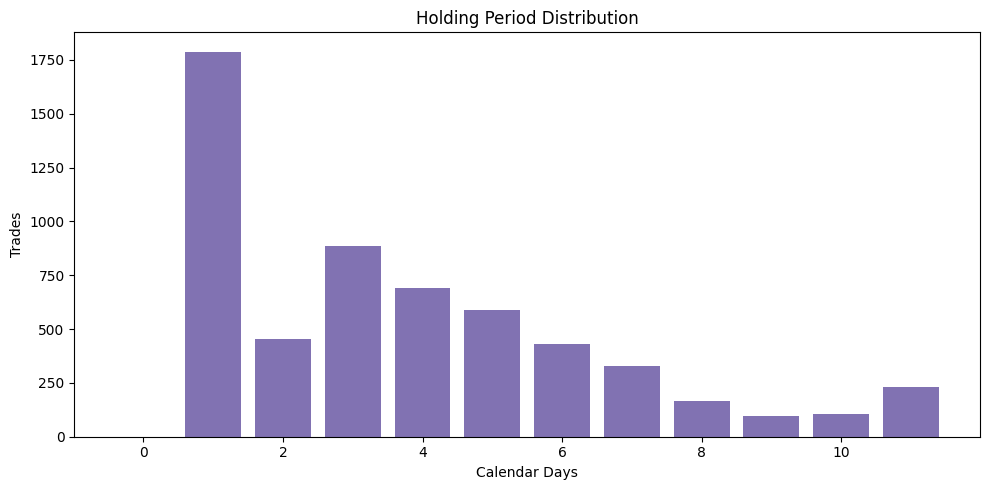

In [67]:
plt.figure(figsize=(10, 5)); plt.hist(trades['holding_days'].to_numpy(), bins=np.arange(0, 13) - .5, color='#8172b2', rwidth=.8); plt.title('Holding Period Distribution'); plt.xlabel('Calendar Days'); plt.ylabel('Trades'); plt.tight_layout(); plt.show()


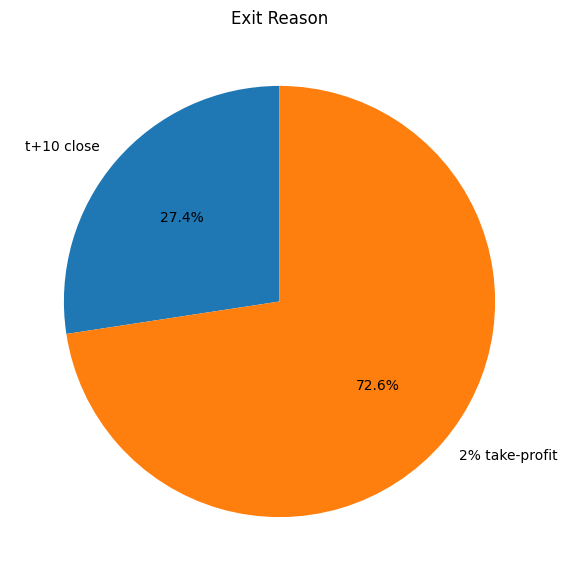

In [68]:
exit_reason = trades.with_columns(pl.when(pl.col('net_pnl') >= POSITION_SIZE * TAKE_PROFIT - 1e-9).then(pl.lit('2% take-profit')).otherwise(pl.lit('t+10 close')).alias('reason')).group_by('reason').len(); plt.figure(figsize=(7, 7)); plt.pie(exit_reason['len'], labels=exit_reason['reason'], autopct='%1.1f%%', startangle=90); plt.title('Exit Reason'); plt.show()


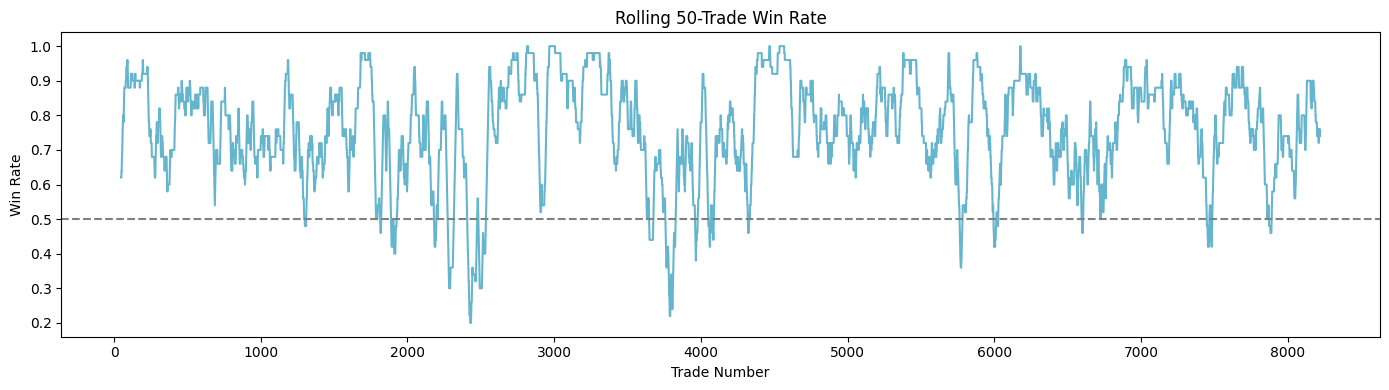

In [69]:
plt.figure(figsize=(14, 4)); plt.plot(np.arange(len(rolling_win)), rolling_win['win_rate'], color='#64b5cd'); plt.axhline(.5, color='gray', ls='--'); plt.title('Rolling 50-Trade Win Rate'); plt.xlabel('Trade Number'); plt.ylabel('Win Rate'); plt.tight_layout(); plt.show()


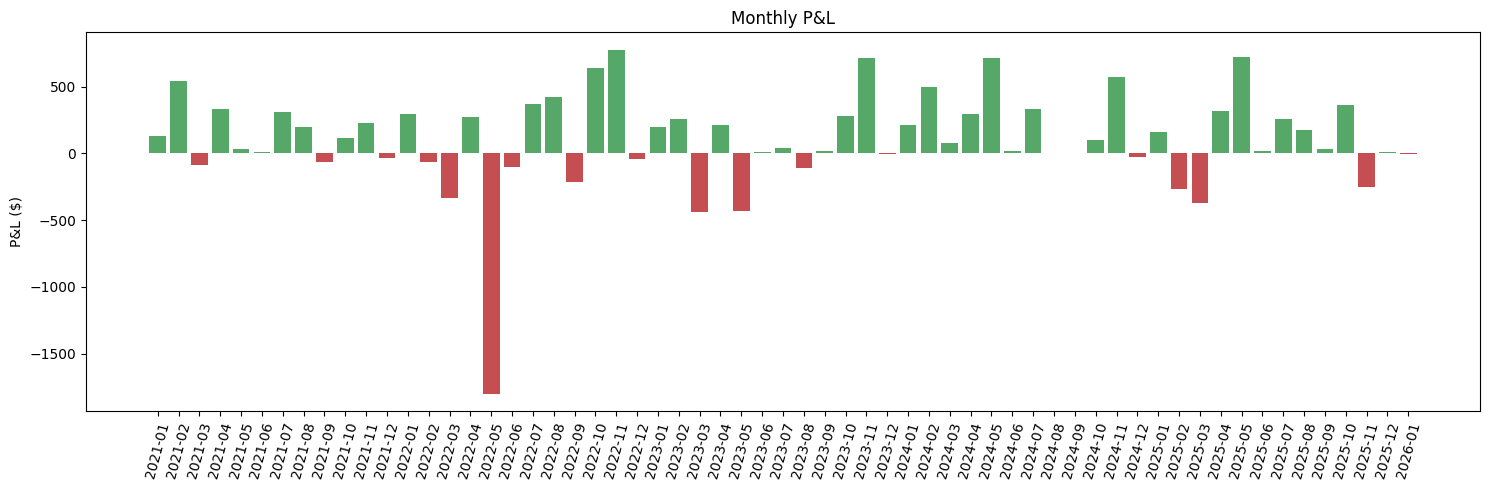

In [70]:
plt.figure(figsize=(15, 5)); plt.bar(monthly['month'].to_list(), monthly['pnl'], color=np.where(monthly['pnl'].to_numpy() >= 0, '#55a868', '#c44e52')); plt.title('Monthly P&L'); plt.xticks(rotation=75); plt.ylabel('P&L ($)'); plt.tight_layout(); plt.show()


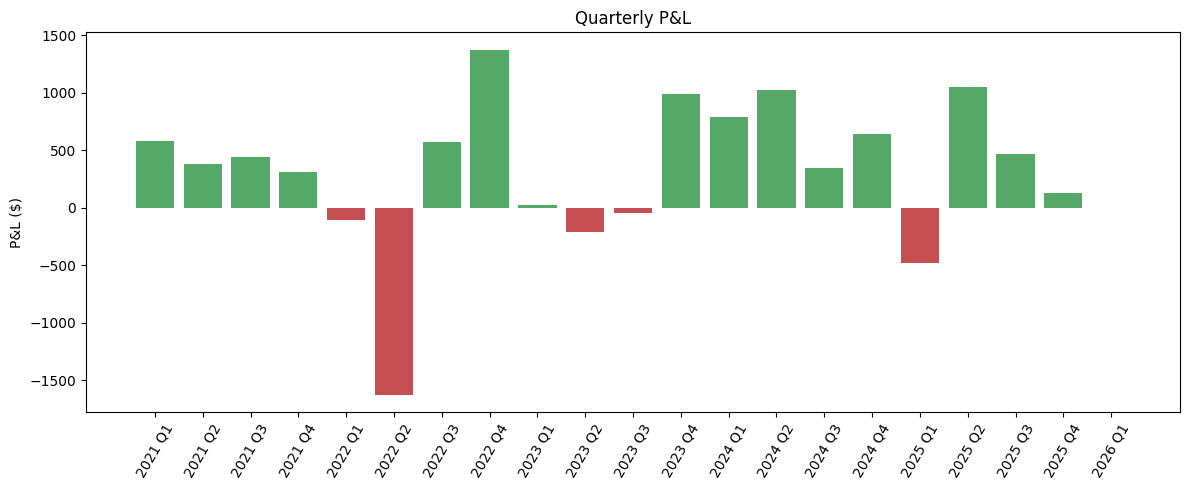

In [71]:
plt.figure(figsize=(12, 5)); plt.bar(quarterly['quarter'].to_list(), quarterly['pnl'], color=np.where(quarterly['pnl'].to_numpy() >= 0, '#55a868', '#c44e52')); plt.title('Quarterly P&L'); plt.xticks(rotation=60); plt.ylabel('P&L ($)'); plt.tight_layout(); plt.show()


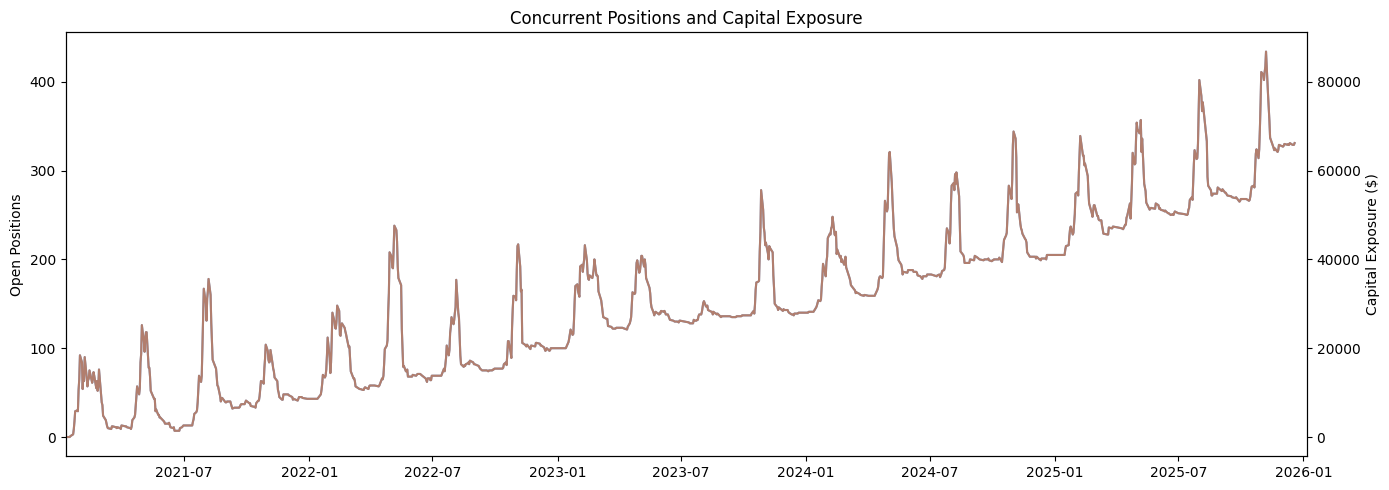

In [73]:
fig, ax = plt.subplots(figsize=(14, 5)); ax.plot(activity['date'], activity['open_positions'], color='#4c72b0'); ax.set_xlim(PLOT_START, PLOT_END); ax.set_title('Concurrent Positions and Capital Exposure'); ax.set_ylabel('Open Positions'); exposure_ax = ax.twinx(); exposure_ax.plot(activity['date'], activity['capital_exposure'], color='#dd8452', alpha=.7); exposure_ax.set_ylabel('Capital Exposure ($)'); fig.tight_layout(); plt.show()


shape: (14, 5)
┌─────────────────────────────┬──────────────┬───────────────────┬──────────────────┬──────────┐
│ period                      ┆ observations ┆ mean_daily_return ┆ daily_volatility ┆ sharpe   │
│ ---                         ┆ ---          ┆ ---               ┆ ---              ┆ ---      │
│ str                         ┆ i64          ┆ f64               ┆ f64              ┆ f64      │
╞═════════════════════════════╪══════════════╪═══════════════════╪══════════════════╪══════════╡
│ All trading days            ┆ 2234         ┆ 0.000053          ┆ 0.000643         ┆ 1.310537 │
│ Exit days only (diagnostic) ┆ 756          ┆ 0.000157          ┆ 0.001098         ┆ 2.267012 │
│ 2014                        ┆ 191          ┆ 0.0               ┆ 0.0              ┆ 0.0      │
│ 2015                        ┆ 189          ┆ 0.0               ┆ 0.0              ┆ 0.0      │
│ 2016                        ┆ 186          ┆ 0.0               ┆ 0.0              ┆ 0.0      │
│ …            

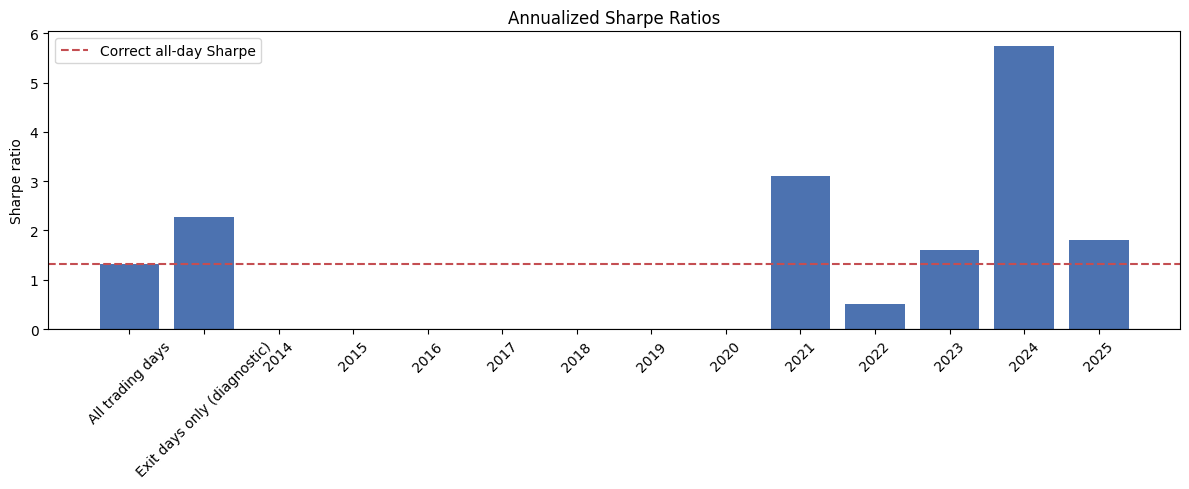

In [74]:
def annualized_sharpe(daily_returns):
    daily_returns = np.asarray(daily_returns, dtype=float)
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    if len(daily_returns) < 2 or daily_returns.std(ddof=1) == 0:
        return 0.0
    return float(daily_returns.mean() / daily_returns.std(ddof=1) * np.sqrt(252))

all_day_returns = equity['daily_return'].to_numpy()
exit_pnl = equity.filter(pl.col('pnl') != 0)['pnl'].to_numpy()
exit_equity = INITIAL_CAPITAL + np.cumsum(exit_pnl)
exit_previous = np.r_[INITIAL_CAPITAL, exit_equity[:-1]]
exit_day_returns = (exit_equity - exit_previous) / exit_previous

sharpe_rows = [{
    'period': 'All trading days',
    'observations': len(all_day_returns),
    'mean_daily_return': float(np.mean(all_day_returns)),
    'daily_volatility': float(np.std(all_day_returns, ddof=1)),
    'sharpe': annualized_sharpe(all_day_returns),
}, {
    'period': 'Exit days only (diagnostic)',
    'observations': len(exit_day_returns),
    'mean_daily_return': float(np.mean(exit_day_returns)),
    'daily_volatility': float(np.std(exit_day_returns, ddof=1)),
    'sharpe': annualized_sharpe(exit_day_returns),
}]

for year in sorted(equity.select(pl.col('exit_date').dt.year().alias('year'))['year'].unique().to_list()):
    year_returns = equity.filter(pl.col('exit_date').dt.year() == year)['daily_return'].to_numpy()
    if len(year_returns) > 1:
        sharpe_rows.append({'period': str(year), 'observations': len(year_returns), 'mean_daily_return': float(np.mean(year_returns)), 'daily_volatility': float(np.std(year_returns, ddof=1)), 'sharpe': annualized_sharpe(year_returns)})

sharpe_table = pl.DataFrame(sharpe_rows)
print(sharpe_table)

plt.figure(figsize=(12, 5))
plt.bar(sharpe_table['period'], sharpe_table['sharpe'], color='#4c72b0')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(sharpe_table[0, 'sharpe'], color='#c44e52', linestyle='--', label='Correct all-day Sharpe')
plt.title('Annualized Sharpe Ratios')
plt.ylabel('Sharpe ratio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [75]:
equity

exit_date,pnl,equity,daily_return,drawdown
date,f64,f64,f64,f64
2014-01-07,0.0,50000.0,0.0,0.0
2014-01-08,0.0,50000.0,0.0,0.0
2014-01-09,0.0,50000.0,0.0,0.0
2014-01-14,0.0,50000.0,0.0,0.0
2014-01-15,0.0,50000.0,0.0,0.0
…,…,…,…,…
2025-12-12,4.0,56271.974411,0.000071,-0.008114
2025-12-16,-9.598636,56262.375775,-0.000171,-0.008283
2025-12-17,4.0,56266.375775,0.000071,-0.008213
